In [2]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42

df_rating = pd.read_csv('./ratings.csv')
df_books = pd.read_csv('./books.csv')
df_tags = pd.read_csv('./tags.csv')
df_to_read = pd.read_csv('./to_read.csv')
df_book_tags = pd.read_csv('./book_tags.csv')

# EDA (разведочный анализ данных)

Перед тем как строить модель, нужно посмотреть, что вообще внутри данных: сколько
строк, есть ли пропуски/аномалии, какое распределение оценок, сколько книг в
среднем оценивает один пользователь. Без этого шага все дальнейшие числа (вроде
"плотность матрицы 0.18%") берутся из воздуха — здесь мы их выводим и объясняем.

In [3]:
print("Размеры таблиц (строки, столбцы):")
print(f"  ratings:    {df_rating.shape}")
print(f"  books:      {df_books.shape}")
print(f"  tags:       {df_tags.shape}")
print(f"  to_read:    {df_to_read.shape}")
print(f"  book_tags:  {df_book_tags.shape}")

print("\nПропуски (NaN) в ratings и books:")
print(df_rating.isna().sum())
print(df_books[['id', 'title', 'authors', 'average_rating']].isna().sum())

Размеры таблиц (строки, столбцы):
  ratings:    (981756, 3)
  books:      (10000, 23)
  tags:       (34252, 2)
  to_read:    (912705, 2)
  book_tags:  (999912, 3)

Пропуски (NaN) в ratings и books:
book_id    0
user_id    0
rating     0
dtype: int64
id                0
title             0
authors           0
average_rating    0
dtype: int64


In [4]:
n_unique_users = df_rating['user_id'].nunique()
n_unique_books = df_rating['book_id'].nunique()
n_ratings = len(df_rating)

max_possible_cells = n_unique_users * n_unique_books
density_pct = n_ratings / max_possible_cells * 100

print(f"Уникальных юзеров: {n_unique_users}")
print(f"Уникальных книг: {n_unique_books}")
print(f"Всего оценок: {n_ratings}")
print(f"Максимум возможных пар (юзер, книга): {max_possible_cells}")
print(f"Плотность = {n_ratings} / {max_possible_cells} = {density_pct:.2f}%")

print(f"\nОценок на одного юзера в среднем: {n_ratings / n_unique_users:.1f}")
print(f"Распределение количества оценок на юзера:")
print(df_rating.groupby('user_id').size().describe())

print(f"\nРаспределение самих оценок (1-5):")
print(df_rating['rating'].value_counts().sort_index())

Уникальных юзеров: 53424
Уникальных книг: 10000
Всего оценок: 981756
Максимум возможных пар (юзер, книга): 534240000
Плотность = 981756 / 534240000 = 0.18%

Оценок на одного юзера в среднем: 18.4
Распределение количества оценок на юзера:
count    53424.000000
mean        18.376685
std         26.268690
min          2.000000
25%          3.000000
50%          8.000000
75%         22.000000
max        200.000000
dtype: float64

Распределение самих оценок (1-5):
rating
1     19575
2     63231
3    248623
4    357366
5    292961
Name: count, dtype: int64


## EDA: books.csv — годы издания, языки, авторы, дубликаты

In [ ]:
print("original_publication_year — статистика:")
print(df_books['original_publication_year'].describe())

print(f"\nПропуски в original_publication_year: {df_books['original_publication_year'].isna().sum()}")

print("\nТоп-10 языков книг:")
print(df_books['language_code'].value_counts().head(10))

print(f"\nДубликаты по title: {df_books['title'].duplicated().sum()}")
print(f"Дубликаты по isbn: {df_books['isbn'].duplicated().sum()}")

original_publication_year — статистика:
count    9979.000000
mean     1981.987674
std       152.576665
min     -1750.000000
25%      1990.000000
50%      2004.000000
75%      2011.000000
max      2017.000000
Name: original_publication_year, dtype: float64

Книг с подозрительным годом издания: 0

Пропуски в original_publication_year: 21

Топ-10 языков книг:
language_code
eng      6341
en-US    2070
en-GB     257
ara        64
en-CA      58
fre        25
ind        21
spa        20
ger        13
per         7
Name: count, dtype: int64

Дубликаты по title (одно и то же название встречается несколько раз): 36
Дубликаты по isbn: 699


## EDA: противоречия в данных и связь to_read / ratings

In [ ]:
# Противоречие: один и тот же юзер оценил одну и ту же книгу дважды разными оценками
dup_pairs = df_rating.duplicated(subset=['user_id', 'book_id'], keep=False)
print(f"Строк с повторной парой (user_id, book_id): {dup_pairs.sum()}")
if dup_pairs.sum():
    print(df_rating[dup_pairs].sort_values(['user_id', 'book_id']).head(6))

# Книги с очень малым числом реальных оценок в ratings.csv, при этом с высоким average_rating
low_votes_high_rating = df_books[(df_books['ratings_count'] < 50) & (df_books['average_rating'] >= 4.5)]
print(f"\nКниг с <50 оценками и average_rating>=4.5 (ненадёжно высокий рейтинг): {len(low_votes_high_rating)}")

# Сколько книг из to_read юзеры потом реально оценили
to_read_pairs = set(zip(df_to_read['user_id'], df_to_read['book_id']))
rated_pairs = set(zip(df_rating['user_id'], df_rating['book_id']))
overlap = len(to_read_pairs & rated_pairs)

print(f"\nПар (user, book) в to_read: {len(to_read_pairs)}")
print(f"Из них уже есть и в ratings (прочитано и оценено): {overlap} "
      f"({overlap / len(to_read_pairs) * 100:.1f}%)")

Строк с повторной парой (user_id, book_id): 4487
        book_id  user_id  rating
459828     4608        7       3
459829     4608        7       2
883645     8946       16       5
883646     8946       16       3
702002     7063       17       5
702003     7063       17       5

Книг с <50 оценками и average_rating>=4.5 (ненадёжно высокий рейтинг): 0

Пар (user, book) в to_read: 912705
Из них уже есть и в ratings (прочитано и оценено): 257 (0.0%)


## EDA: графики

Таблицы `.describe()` и `.value_counts()` дают точные числа, но графики быстрее
показывают форму распределения — скошенность, выбросы, "длинный хвост".

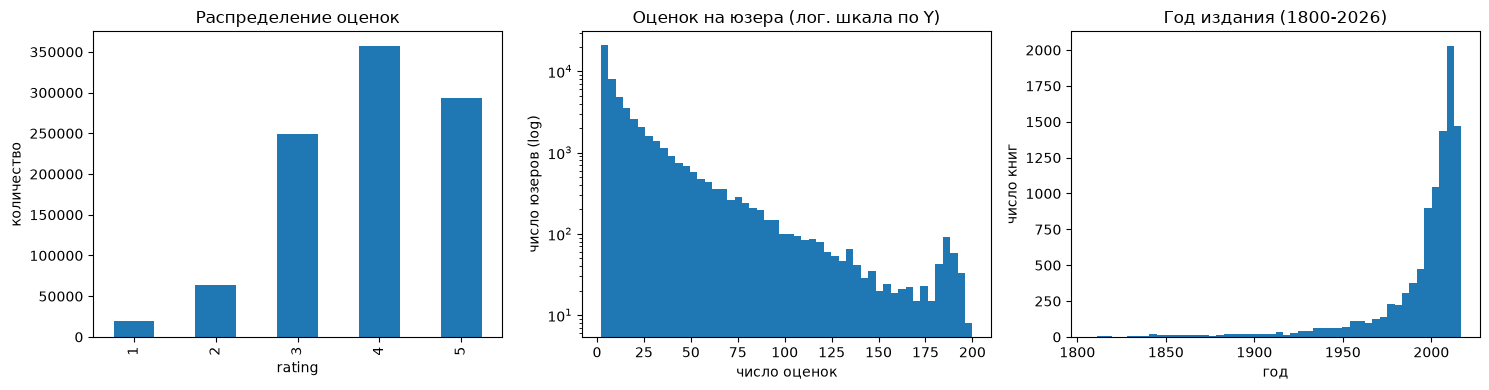

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Распределение оценок (1-5)
df_rating['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Распределение оценок')
axes[0].set_xlabel('rating')
axes[0].set_ylabel('количество')

# 2. Сколько оценок ставит один юзер — сильно скошено вправо (long tail),
# поэтому логарифмическая шкала по Y, иначе редкие "суперактивные" юзеры
# сплющат весь график в одну линию у нуля
ratings_per_user = df_rating.groupby('user_id').size()
axes[1].hist(ratings_per_user, bins=50)
axes[1].set_yscale('log')
axes[1].set_title('Оценок на юзера (лог. шкала по Y)')
axes[1].set_xlabel('число оценок')
axes[1].set_ylabel('число юзеров (log)')

# 3. Годы издания (отфильтровав явные аномалии для читаемости графика)
years = df_books['original_publication_year'].dropna()
years = years[(years > 1800) & (years <= 2026)]
axes[2].hist(years, bins=50)
axes[2].set_title('Год издания (1800-2026)')
axes[2].set_xlabel('год')
axes[2].set_ylabel('число книг')

plt.tight_layout()
plt.show()

# train/test split (leave-one-out по высоким оценкам)

Раньше в ноутбуке не было никакой проверки качества — "анализ" сводился к сравнению
двух непроверенных алгоритмов между собой. Делаем классический leave-one-out:
для каждого пользователя с >=2 оценками >=4 прячем одну случайную "хорошую" оценку
в test, остальное остаётся в train. Матрицы и similarity строим только на train,
чтобы не было утечки данных (data leakage).

In [10]:
rng = np.random.default_rng(RANDOM_STATE)

df_rating_renamed = df_rating.rename(columns={'book_id': 'id'})

# leave-one-out: для каждого юзера с >=2 оценками >=4 прячем одну в test
eligible = df_rating_renamed[df_rating_renamed['rating'] >= 4]
counts = eligible.groupby('user_id').size()
eligible_users = counts[counts >= 2].index

test_idx = (
    eligible[eligible['user_id'].isin(eligible_users)]
    .groupby('user_id', group_keys=False)[['rating']]
    .apply(lambda g: g.sample(n=1, random_state=RANDOM_STATE))
    .index
)

df_test = df_rating_renamed.loc[test_idx]
df_train = df_rating_renamed.drop(index=test_idx)

print(f"train: {len(df_train)} оценок, test: {len(df_test)} оценок (по одной на {len(test_idx)} юзеров)")

train: 935432 оценок, test: 46324 оценок (по одной на 46324 юзеров)


In [12]:
cf_matrix_clean = df_train.groupby(['user_id', 'id']).agg({'rating': 'mean'}).reset_index()

# factorize превращает колонку значений в пару (номера_строк 0..N-1, список_уникальных_значений).
# user_idx[i] — номер строки будущей матрицы для i-й оценки, user_ids[код] — обратная расшифровка.
user_idx, user_ids = pd.factorize(cf_matrix_clean['user_id'], sort=True)
book_idx, book_ids = pd.factorize(cf_matrix_clean['id'], sort=True)
ratings_vals = cf_matrix_clean['rating'].to_numpy()

user_means = cf_matrix_clean.groupby('user_id')['rating'].mean().reindex(user_ids).to_numpy()

centered_vals = ratings_vals - user_means[user_idx]

n_users, n_books = len(user_ids), len(book_ids)
sparse_matrix = csr_matrix((centered_vals, (user_idx, book_idx)), shape=(n_users, n_books))

density = sparse_matrix.nnz / (n_users * n_books) * 100
print(f"Матрица: {sparse_matrix.shape}, плотность: {density:.2f}%, "
      f"память: {sparse_matrix.data.nbytes / 1e6:.1f} MB (вместо "
      f"{n_users * n_books * 8 / 1e9:.1f} GB для dense)")

Матрица: (53424, 10000), плотность: 0.17%, память: 7.5 MB (вместо 4.3 GB для dense)


In [13]:
user_id_to_idx = {uid: i for i, uid in enumerate(user_ids)}
book_id_to_idx = {bid: i for i, bid in enumerate(book_ids)}
idx_to_book_id = {i: bid for bid, i in book_id_to_idx.items()}

book_title_by_id = df_books.set_index('id')['title'].to_dict()

# popularity fallback для холодного старта (юзеры без train-оценок)
popularity_rank = (
    df_train.groupby('id')['rating']
    .agg(['mean', 'count'])
    .query('count >= 20')  # отсекаем книги с парой случайных 5-ок
    .sort_values(['mean', 'count'], ascending=False)
)
popular_book_ids = popularity_rank.index.tolist()


def popularity_recommend(n_recommendations=5, exclude_ids=()):
    exclude = set(exclude_ids)
    picked = [bid for bid in popular_book_ids if bid not in exclude][:n_recommendations]
    return [(bid, popularity_rank.loc[bid, 'mean']) for bid in picked]

# user-based flow

Раньше similarity считался как `cosine_similarity(matrix.fillna(0))` — плотная
53424×53424 матрица (~22 GB во float64), которая физически не могла быть
использована на реальных объёмах, и делалась поверх matrix с fillna(0) (см. выше:
искажает similarity). Здесь similarity одного юзера против всех считаем "на лету"
через одно матрично-векторное умножение sparse-матрицы — той же математике, что и
`cosine_similarity`, но без материализации полной NxN матрицы в памяти.

In [ ]:
def similar_users_for(user_idx_, n_similar_users=10):
    """Cosine similarity одного юзера против всех через готовую функцию sklearn.

    Считаем similarity только для одной строки (нашего юзера) против всей
    матрицы — а не для всех 53424 юзеров друг против друга сразу, иначе
    результат (53424 x 53424 чисел) не поместится в память.
    """
    user_vec = sparse_matrix[user_idx_]  # одна строка — вектор нашего юзера
    sims = cosine_similarity(user_vec, sparse_matrix).ravel()  # sims[j] = похожесть на юзера j
    sims[user_idx_] = -1  # исключаем самого себя из "похожих на себя"

    top_idx = np.argsort(-sims)[:n_similar_users]  # индексы N самых похожих, по убыванию
    return top_idx, sims[top_idx]

In [15]:
demo_idx, demo_sims = similar_users_for(user_id_to_idx[1], n_similar_users=5)
print("Топ-5 похожих на юзера 1:")
for i, s in zip(demo_idx, demo_sims):
    print(f"  user_id={user_ids[i]}: similarity={s:.3f}")

Топ-5 похожих на юзера 1:
  user_id=34920: similarity=0.655
  user_id=511: similarity=0.577
  user_id=9687: similarity=0.577
  user_id=22050: similarity=0.577
  user_id=40249: similarity=0.546


In [ ]:
def recommend_books(user_id, n_recommendations=5, n_similar_users=10):
    if user_id not in user_id_to_idx:
        return popularity_recommend(n_recommendations)  # холодный старт

    u_idx = user_id_to_idx[user_id]
    similar_idx, similar_sims = similar_users_for(u_idx, n_similar_users)

    # Книги, которые целевой юзер уже оценил (по train)
    rated_book_idx = set(sparse_matrix[u_idx].indices)

    neighbours = sparse_matrix[similar_idx]  # (n_similar_users, n_books), центрированные оценки
    neighbours_rated_mask = (neighbours != 0)

    weights_matrix = neighbours_rated_mask.multiply(similar_sims[:, None])
    weight_sums = np.asarray(weights_matrix.sum(axis=0)).ravel()
    weighted_scores = np.asarray((neighbours.multiply(weights_matrix)).sum(axis=0)).ravel()

    with np.errstate(invalid='ignore', divide='ignore'):
        avg_centered = np.where(weight_sums > 0, weighted_scores / weight_sums, np.nan)

    # обратно из centered в шкалу рейтинга
    avg_scores = avg_centered + user_means[u_idx]

    candidate_idx = [i for i in range(n_books) if i not in rated_book_idx and not np.isnan(avg_scores[i])]
    candidate_idx.sort(key=lambda i: avg_scores[i], reverse=True)
    top_idx = candidate_idx[:n_recommendations]

    recs = [(idx_to_book_id[i], avg_scores[i]) for i in top_idx]

    if len(recs) < n_recommendations:  # не набралось достаточно рекомендаций от соседей
        exclude = {idx_to_book_id[i] for i in rated_book_idx} | {bid for bid, _ in recs}
        recs += popularity_recommend(n_recommendations - len(recs), exclude_ids=exclude)

    return recs


# Пример
recs = recommend_books(user_id=1, n_recommendations=5)
for book_id, score in recs:
    print(f"{book_title_by_id[book_id]}: {score:.2f}")

Fences (The Century Cycle #6): 4.83
The Orange Girl: 4.64
The Passion of Artemisia: 4.50
A Wrinkle in Time: The Graphic Novel: 4.00
The Time of My Life: 3.93


# item-based flow

Книг всего 10000 (в отличие от 53k юзеров), так что полная item-item матрица
похожести (10000×10000 ≈ 800 MB dense) физически посчитать можно — в отличие от
user-user. Но раньше она считалась на `matrix.fillna(0).T` (та же проблема
0=негативная оценка), и сама `recommend_books_item_based` делала двойной цикл
по всем юзерам × всем 10000 книгам с `.loc`-обращениями к DataFrame на каждой
итерации — на 50 юзерах уже заметно медленно, на всех 53k юзерах не отработало бы
за разумное время. Здесь similarity считаем на sparse+mean-centered данных,
а сам подбор рекомендаций — одним матричным умножением на юзера.

In [17]:
item_similarity = cosine_similarity(sparse_matrix.T, dense_output=True)  # 10000x10000, ещё посильно как dense
np.fill_diagonal(item_similarity, 0)  # книга не должна рекомендовать сама себя как "похожую"

In [18]:
print(f"item_similarity: {item_similarity.shape}, {item_similarity.nbytes / 1e6:.0f} MB dense")
print(pd.DataFrame(item_similarity[:5, :5],
                    index=book_ids[:5], columns=book_ids[:5]))

item_similarity: (10000, 10000), 800 MB dense
          1         2         3         4         5
1  0.000000  0.284860 -0.123322  0.271639 -0.016727
2  0.284860  0.000000 -0.012403  0.182386  0.024749
3 -0.123322 -0.012403  0.000000 -0.135189 -0.040553
4  0.271639  0.182386 -0.135189  0.000000  0.091729
5 -0.016727  0.024749 -0.040553  0.091729  0.000000


In [19]:
def recommend_books_item_based(user_id, n_recommendations=5, n_similar_items=10):
    if user_id not in user_id_to_idx:
        return popularity_recommend(n_recommendations)  # холодный старт

    u_idx = user_id_to_idx[user_id]
    user_row = sparse_matrix[u_idx]
    rated_idx = user_row.indices
    rated_centered = user_row.data  # centered-оценки юзера по рейтингам, что он поставил

    if len(rated_idx) == 0:
        return popularity_recommend(n_recommendations)

    # Для каждой не оценённой книги: похожесть на N ближайших ИЗ оценённых юзером книг,
    # взвешенная сумма его оценок этих книг. Раньше это был цикл по всем 10000 книгам
    # с pandas .loc на каждой итерации; здесь — срез матрицы + матричное умножение.
    sims_to_rated = item_similarity[:, rated_idx]  # (n_books, n_rated)

    if n_similar_items < len(rated_idx):
        # оставляем только top-k похожих оценённых книг на каждую кандидатную книгу
        kth = len(rated_idx) - n_similar_items
        threshold = np.partition(sims_to_rated, kth, axis=1)[:, kth][:, None]
        sims_to_rated = np.where(sims_to_rated >= threshold, sims_to_rated, 0.0)

    weight_sums = sims_to_rated.sum(axis=1)
    weighted_scores = sims_to_rated @ rated_centered

    with np.errstate(invalid='ignore', divide='ignore'):
        avg_centered = np.where(weight_sums > 0, weighted_scores / weight_sums, np.nan)

    avg_scores = avg_centered + user_means[u_idx]
    avg_scores[rated_idx] = np.nan  # исключаем уже оценённые книги

    candidate_idx = np.where(~np.isnan(avg_scores))[0]
    candidate_idx = candidate_idx[np.argsort(-avg_scores[candidate_idx])][:n_recommendations]

    recs = [(idx_to_book_id[i], avg_scores[i]) for i in candidate_idx]

    if len(recs) < n_recommendations:
        exclude = {idx_to_book_id[i] for i in rated_idx} | {bid for bid, _ in recs}
        recs += popularity_recommend(n_recommendations - len(recs), exclude_ids=exclude)

    return recs


# Пример
recs = recommend_books_item_based(user_id=1, n_recommendations=20)
for book_id, score in recs:
    print(f"{book_title_by_id[book_id]}: {score:.2f}")

Faith: 11.51
How I Became a Pirate: 7.35
How We Are Hungry: 7.25
The Monuments Men: Allied Heroes, Nazi Thieves, and the Greatest Treasure Hunt in History: 6.03
Warrior of the Light: 5.45
The Jane Austen Book Club: 5.10
Marie Antoinette: The Journey: 4.80
The Bookman’s Tale: 4.64
Slammerkin: 4.50
Chocolat (Chocolat, #1): 4.46
Brida: 4.39
Wide Sargasso Sea: 4.39
What I Loved: 4.25
Be Careful What You Wish For (The Clifton Chronicles, #4): 4.15
Best Kept Secret (The Clifton Chronicles, #3): 4.15
Once and Always (Sequels, #1): 4.14
The Narrow Road to the Deep North: 4.10
Something Wonderful (Sequels, #2): 4.07
Almost Heaven (Sequels, #3): 4.07
The Madness of Lord Ian Mackenzie (Mackenzies & McBrides, #1): 4.00


# content-based flow (теги) + гибрид

`tags.csv` / `book_tags.csv` были загружены в начале ноутбука, но нигде не
использовались — все рекомендации строились только на поведении пользователей
(CF), хотя у нас есть независимый сигнал: жанры/теги самих книг. Это особенно
ценно для холодного старта (новый юзер с парой оценок) и для книг с малым числом
рейтингов, где CF-сигнал слабый.

Строим book×tag матрицу по топ-N тегам (по суммарному `count`), считаем
item-item similarity по тегам так же, как раньше считали по рейтингам,
и делаем гибрид: взвешенная сумма CF item-based score и content-based score.

In [20]:
# book_tags использует goodreads_book_id, а не наш "id" — мэппим через books.csv
goodreads_to_id = df_books.set_index('book_id')['id'].to_dict()

book_tags = df_book_tags.copy()
book_tags['id'] = book_tags['goodreads_book_id'].map(goodreads_to_id)
book_tags = book_tags.dropna(subset=['id'])
book_tags['id'] = book_tags['id'].astype(int)
book_tags = book_tags[book_tags['id'].isin(book_id_to_idx)]  # только книги, что есть в нашей матрице
# в исходных данных GoodBooks-10k изредка встречается count=-1 (артефакт сбора данных)
book_tags = book_tags[book_tags['count'] > 0]

TOP_N_TAGS = 500
top_tags = (
    book_tags.groupby('tag_id')['count'].sum()
    .nlargest(TOP_N_TAGS)
    .index
)
book_tags = book_tags[book_tags['tag_id'].isin(top_tags)]

tag_cat = book_tags['tag_id'].astype('category')
tag_ids = tag_cat.cat.categories
tag_id_to_idx = {tid: i for i, tid in enumerate(tag_ids)}

bt_book_idx = book_tags['id'].map(book_id_to_idx).to_numpy()
bt_tag_idx = tag_cat.cat.codes.to_numpy()
bt_counts = book_tags['count'].to_numpy(dtype=float)

book_tag_matrix = csr_matrix(
    (bt_counts, (bt_book_idx, bt_tag_idx)),
    shape=(n_books, len(tag_ids)),
)
# log1p сглаживает разброс: count варьируется от единиц до сотен тысяч
book_tag_matrix.data = np.log1p(book_tag_matrix.data)

content_similarity = cosine_similarity(book_tag_matrix, dense_output=True)
np.fill_diagonal(content_similarity, 0)

print(f"content_similarity: {content_similarity.shape}, "
      f"построено по {len(tag_ids)} тегам для {book_tag_matrix.getnnz(axis=1).astype(bool).sum()} книг")

content_similarity: (10000, 10000), построено по 500 тегам для 10000 книг


In [21]:
def recommend_books_hybrid(user_id, n_recommendations=5, n_similar_items=10, content_weight=0.3):
    """CF item-based score + content-based (tag) score, взвешенная сумма.

    content_weight=0 сводится к чистому CF item-based; content_weight=1 — к чистому
    content-based. 0.3 — небольшой сдвиг в сторону CF, т.к. поведенческий сигнал обычно
    точнее, но теги подмешивают разнообразие и помогают с холодными книгами/юзерами.
    """
    if user_id not in user_id_to_idx:
        return popularity_recommend(n_recommendations)

    u_idx = user_id_to_idx[user_id]
    user_row = sparse_matrix[u_idx]
    rated_idx = user_row.indices
    rated_centered = user_row.data

    if len(rated_idx) == 0:
        return popularity_recommend(n_recommendations)

    def _weighted_avg(sim_matrix, values, top_k):
        sims = sim_matrix[:, rated_idx]
        if top_k < len(rated_idx):
            kth = len(rated_idx) - top_k
            threshold = np.partition(sims, kth, axis=1)[:, kth][:, None]
            sims = np.where(sims >= threshold, sims, 0.0)
        w_sum = sims.sum(axis=1)
        w_score = sims @ values
        with np.errstate(invalid='ignore', divide='ignore'):
            return np.where(w_sum > 0, w_score / w_sum, np.nan), w_sum > 0

    cf_avg_centered, cf_has_signal = _weighted_avg(item_similarity, rated_centered, n_similar_items)
    cf_scores = cf_avg_centered + user_means[u_idx]

    rated_ratings_raw = rated_centered + user_means[u_idx]  # шкала 1-5 для контентного скора
    content_avg, content_has_signal = _weighted_avg(content_similarity, rated_ratings_raw, n_similar_items)

    # нормализуем оба сигнала в [0, 1] перед смешиванием, т.к. они на разных шкалах
    def _minmax(x, mask):
        if mask.sum() == 0:
            return np.zeros_like(x)
        lo, hi = np.nanmin(x[mask]), np.nanmax(x[mask])
        return np.where(mask, (x - lo) / (hi - lo) if hi > lo else 0.5, 0.0)

    cf_norm = _minmax(cf_scores, cf_has_signal)
    content_norm = _minmax(content_avg, content_has_signal)
    has_any_signal = cf_has_signal | content_has_signal

    hybrid_score = (1 - content_weight) * cf_norm + content_weight * content_norm
    hybrid_score = np.where(has_any_signal, hybrid_score, np.nan)
    hybrid_score[rated_idx] = np.nan

    candidate_idx = np.where(~np.isnan(hybrid_score))[0]
    candidate_idx = candidate_idx[np.argsort(-hybrid_score[candidate_idx])][:n_recommendations]
    recs = [(idx_to_book_id[i], hybrid_score[i]) for i in candidate_idx]

    if len(recs) < n_recommendations:
        exclude = {idx_to_book_id[i] for i in rated_idx} | {bid for bid, _ in recs}
        recs += popularity_recommend(n_recommendations - len(recs), exclude_ids=exclude)

    return recs


# Пример
recs = recommend_books_hybrid(user_id=1, n_recommendations=10)
for book_id, score in recs:
    print(f"{book_title_by_id[book_id]}: {score:.3f}")

Faith: 0.874
The Deal (Off-Campus, #1): 0.838
Tampa: 0.836
What I Loved: 0.835
The Mothers: 0.830
Brida: 0.829
How We Are Hungry: 0.827
The Jane Austen Book Club: 0.827
The Rosie Project (Don Tillman, #1): 0.826
A Widow for One Year: 0.825


# result

In [22]:
user_id = 50  # или любой другой
N = 20

user_based_recs = recommend_books(user_id, n_recommendations=N)
item_based_recs = recommend_books_item_based(user_id, n_recommendations=N)
hybrid_recs = recommend_books_hybrid(user_id, n_recommendations=N)

user_based_ids = {book_id for book_id, _ in user_based_recs}
item_based_ids = {book_id for book_id, _ in item_based_recs}
hybrid_ids = {book_id for book_id, _ in hybrid_recs}

common_ui = user_based_ids & item_based_ids

print(f"User-based топ-{N}: {sorted(user_based_ids)}")
print(f"Item-based топ-{N}: {sorted(item_based_ids)}")
print(f"Hybrid топ-{N}: {sorted(hybrid_ids)}")
print(f"\nСовпадения user-based/item-based: {common_ui}")
print(f"Jaccard(user-based, item-based) = {len(common_ui) / len(user_based_ids | item_based_ids) * 100:.1f}%")

User-based топ-20: [2797, 5241, 5364, 5994, 6094, 6572, 7242, 7639, 7701, 7913, 8220, 8570, 8687, 8815, 9081, 9123, 9311, 9649, 9775, 9891]
Item-based топ-20: [2300, 2584, 2707, 3043, 3371, 3670, 4509, 4614, 5556, 5562, 6114, 6400, 6636, 7008, 7397, 7520, 9551, 9823, 9905, 9995]
Hybrid топ-20: [387, 592, 646, 2286, 3379, 3508, 4509, 4614, 4755, 5556, 5863, 6265, 6636, 7701, 8589, 8733, 9311, 9551, 9905, 9995]

Совпадения user-based/item-based: set()
Jaccard(user-based, item-based) = 0.0%


In [23]:
results = []
N = 20

for user_id in range(1, 51):
    user_based_recs = recommend_books(user_id, n_recommendations=N)
    item_based_recs = recommend_books_item_based(user_id, n_recommendations=N)

    if user_based_recs and item_based_recs:
        user_based_ids = {book_id for book_id, _ in user_based_recs}
        item_based_ids = {book_id for book_id, _ in item_based_recs}

        common = user_based_ids & item_based_ids
        union = user_based_ids | item_based_ids
        # Раньше было `len(common) / 10 * 100`, что при N=1000 и common>10 давало
        # значения вроде 830% — не поддающиеся интерпретации как процент. Jaccard
        # index (|A∩B| / |A∪B|) корректно ограничен [0, 100]%.
        jaccard = len(common) / len(union) * 100 if union else 0.0

        results.append({
            'user_id': user_id,
            'overlaps': len(common),
            'jaccard_percent': jaccard,
        })

df_results = pd.DataFrame(results)
print(df_results)
print(f"\nСредний Jaccard overlap: {df_results['jaccard_percent'].mean():.1f}%")

    user_id  overlaps  jaccard_percent
0         1         0         0.000000
1         2         1         2.564103
2         3         0         0.000000
3         4         1         2.564103
4         5         0         0.000000
5         6         0         0.000000
6         7         0         0.000000
7         8         0         0.000000
8         9         1         2.564103
9        10         1         2.564103
10       11         2         5.263158
11       12         0         0.000000
12       13         0         0.000000
13       14         1         2.564103
14       15         1         2.564103
15       16         0         0.000000
16       17         0         0.000000
17       18         0         0.000000
18       19         0         0.000000
19       20         0         0.000000
20       21         0         0.000000
21       22         0         0.000000
22       23         0         0.000000
23       24         0         0.000000
24       25         0    

# Оценка качества: precision@k / recall@k на отложенном test

Раньше в ноутбуке не было ни одной метрики качества — только overlap между двумя
непроверенными алгоритмами, что ничего не говорит о том, насколько рекомендации
вообще хороши. Используем leave-one-out test, собранный в начале: для каждого
юзера в test лежит ровно одна книга, которую он реально оценил высоко (>=4),
но которую мы скрыли из train. Если метод предсказывает эту книгу в top-k — успех.

Для leave-one-out с 1 relevant item на юзера precision@k и recall@k эквивалентны
hit-rate@k / k и hit-rate@k соответственно, но считаем оба явно для наглядности.

In [24]:
def evaluate(recommend_fn, k=10, n_eval_users=300, **fn_kwargs):
    """precision@k / recall@k по leave-one-out test, на подвыборке юзеров для скорости."""
    test_by_user = df_test.set_index('user_id')['id'].to_dict()
    eval_users = list(test_by_user.keys())
    rng.shuffle(eval_users)
    eval_users = eval_users[:n_eval_users]

    hits = 0
    evaluated = 0
    for uid in eval_users:
        if uid not in user_id_to_idx:
            continue  # юзер целиком ушёл в test (весь его train пуст) — не наш случай при leave-one-out, но на всякий
        held_out_book = test_by_user[uid]
        recs = recommend_fn(uid, n_recommendations=k, **fn_kwargs)
        rec_ids = {bid for bid, _ in recs}
        hits += int(held_out_book in rec_ids)
        evaluated += 1

    precision_at_k = hits / (evaluated * k) if evaluated else 0.0
    recall_at_k = hits / evaluated if evaluated else 0.0  # 1 relevant item per user
    return {'evaluated_users': evaluated, 'hits': hits, f'precision@{k}': precision_at_k, f'recall@{k}': recall_at_k}


K = 10
N_EVAL = 300

metrics = {
    'popularity (baseline)': evaluate(lambda uid, n_recommendations: popularity_recommend(n_recommendations), k=K, n_eval_users=N_EVAL),
    'user-based CF': evaluate(recommend_books, k=K, n_eval_users=N_EVAL),
    'item-based CF': evaluate(recommend_books_item_based, k=K, n_eval_users=N_EVAL),
    'hybrid (CF + tags)': evaluate(recommend_books_hybrid, k=K, n_eval_users=N_EVAL),
}

df_metrics = pd.DataFrame(metrics).T
print(df_metrics)

                       evaluated_users  hits  precision@10  recall@10
popularity (baseline)            300.0   0.0      0.000000   0.000000
user-based CF                    300.0  13.0      0.004333   0.043333
item-based CF                    300.0   2.0      0.000667   0.006667
hybrid (CF + tags)               300.0   6.0      0.002000   0.020000
